# 01 — Policy Evaluation
**Week 4 | Dynamic Programming**

**Policy Evaluation** answers: *How good is a given policy π?*

We iteratively apply the Bellman expectation equation until V converges:

$$V_{k+1}(s) = \sum_a \pi(a|s) \sum_{s'} P(s'|s,a) \left[ R(s,a,s') + \gamma V_k(s') \right]$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

# ---- Reuse Grid World from Week 3 ----
class GridWorld:
    ACTIONS = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}
    ACTION_SYMBOLS = {0:'↑', 1:'↓', 2:'←', 3:'→'}
    def __init__(self, size=5):
        self.size = size; self.start=(0,0); self.goal=(size-1,size-1)
        self.pits = {(1,1),(1,3),(3,1),(3,3)}
    def n_states(self): return self.size**2
    def n_actions(self): return 4
    def transitions(self, s, a):
        """Return list of (prob, next_s, reward, done)."""
        r, c = divmod(s, self.size)
        dr, dc = self.ACTIONS[a]
        nr = max(0, min(self.size-1, r+dr)); nc = max(0, min(self.size-1, c+dc))
        ns = nr*self.size + nc
        if (nr,nc) == self.goal:       return [(1.0, ns, +10.0, True)]
        if (nr,nc) in self.pits:       return [(1.0, ns,  -5.0, True)]
        return [(1.0, ns, -0.1, False)]

env = GridWorld()

In [2]:
def policy_evaluation(env, policy, gamma=0.99, theta=1e-6, max_iter=1000):
    """
    Iterative policy evaluation.
    policy: array of shape (n_states, n_actions) — action probabilities.
    Returns V: array of shape (n_states,)
    """
    V = np.zeros(env.n_states())
    history = [V.copy()]
    for iteration in range(max_iter):
        delta = 0.0
        V_new = np.zeros_like(V)
        for s in range(env.n_states()):
            v = 0.0
            for a in range(env.n_actions()):
                for prob, ns, reward, done in env.transitions(s, a):
                    v += policy[s, a] * prob * (reward + (0 if done else gamma * V[s]))
            V_new[s] = v
            delta = max(delta, abs(V_new[s] - V[s]))
        V = V_new
        history.append(V.copy())
        if delta < theta:
            print(f"Converged in {iteration+1} iterations (Δ={delta:.2e})")
            break
    return V, history

In [3]:
# Uniform random policy
n_s, n_a = env.n_states(), env.n_actions()
uniform_policy = np.ones((n_s, n_a)) / n_a

V, history = policy_evaluation(env, uniform_policy)

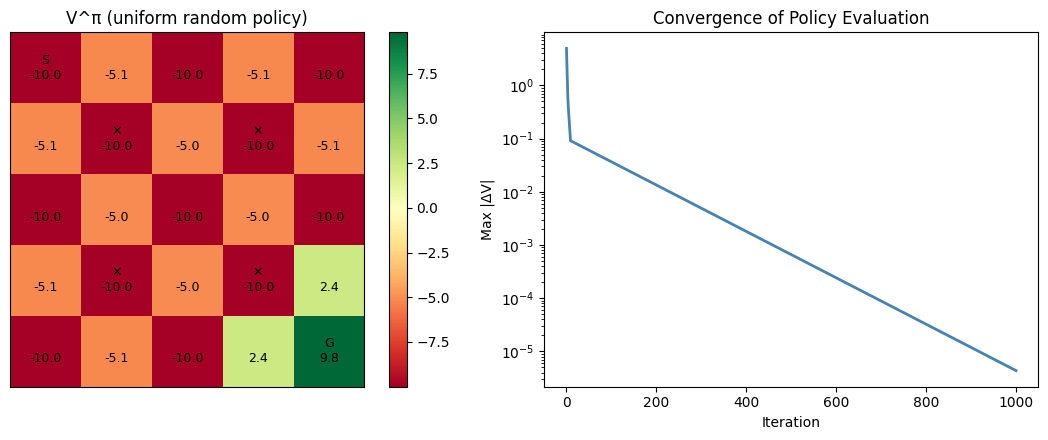

In [4]:
# Visualise final value function
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Heatmap
im = axes[0].imshow(V.reshape(5,5), cmap='RdYlGn')
plt.colorbar(im, ax=axes[0])
for r in range(5):
    for c in range(5):
        label = ''
        if (r,c)==env.goal: label='G'
        elif (r,c)==env.start: label='S'
        elif (r,c) in env.pits: label='✕'
        axes[0].text(c, r, f'{label}\n{V[r*5+c]:.1f}', ha='center', va='center', fontsize=9)
axes[0].set_title('V^π (uniform random policy)'); axes[0].set_xticks([]); axes[0].set_yticks([])

# Convergence curve
max_delta = [np.max(np.abs(history[i+1]-history[i])) for i in range(len(history)-1)]
axes[1].semilogy(max_delta, color='steelblue', linewidth=2)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Max |ΔV|')
axes[1].set_title('Convergence of Policy Evaluation')
plt.tight_layout(); plt.show()

## ✅ Exercises
1. Try γ=0.5, γ=0.9, γ=0.999. How does the value function shape change?
2. Create a policy that always moves RIGHT. Evaluate it. What happens to states on the rightmost column?
3. **Challenge**: implement **in-place** policy evaluation (update V[s] immediately instead of V_new). Does it converge faster?

Converged in 18 iterations (Δ=7.63e-07)
Converged in 111 iterations (Δ=9.26e-07)


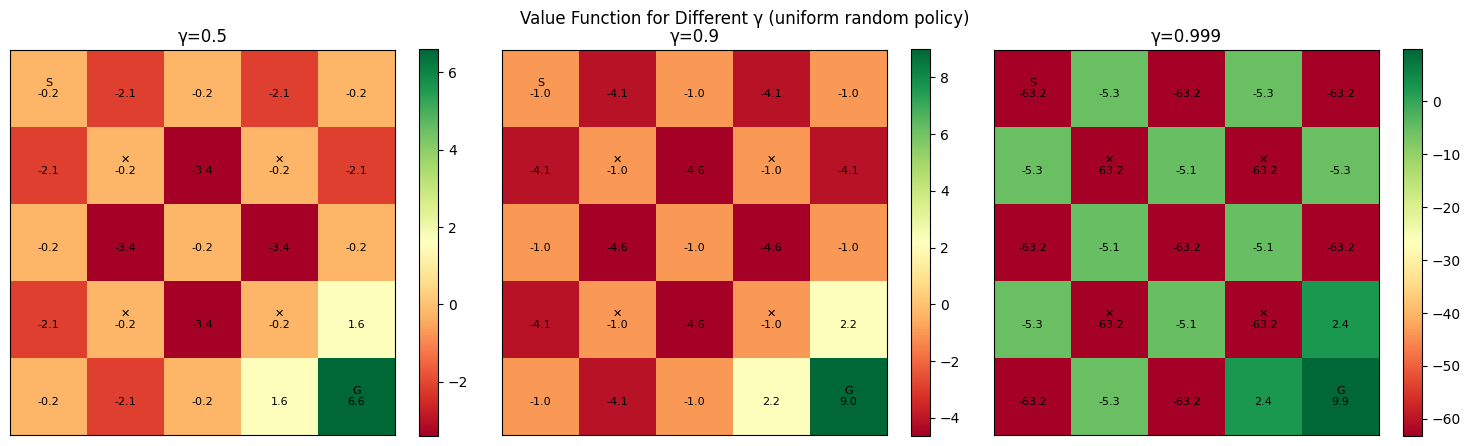

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, gamma in zip(axes, [0.5, 0.9, 0.999]):
    V_g, _ = policy_evaluation(env, uniform_policy, gamma=gamma)
    im = ax.imshow(V_g.reshape(5,5), cmap='RdYlGn')
    plt.colorbar(im, ax=ax)
    for r in range(5):
        for c in range(5):
            label = 'G' if (r,c)==env.goal else ('S' if (r,c)==env.start else ('✕' if (r,c) in env.pits else ''))
            ax.text(c, r, f'{label}\n{V_g[r*5+c]:.1f}', ha='center', va='center', fontsize=8)
    ax.set_title(f'γ={gamma}'); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Value Function for Different γ (uniform random policy)')
plt.tight_layout(); plt.show()

# γ=0.5: very myopic — values are low everywhere, agent barely cares about goal
# γ=0.9: moderate — goal clearly visible, pits show negative values
# γ=0.999: patient — high values spread far from goal, steep gradient across the grid

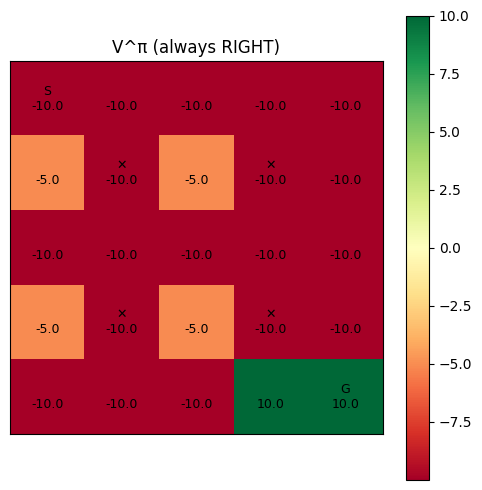

Rightmost column (c=4): agent is stuck — moving right hits the wall and stays in place.
This creates a loop with only step costs (-0.1 per step), so values are very negative.
Except row 4, col 4 which is the goal.


In [6]:
# Always RIGHT (action 3)
right_policy = np.zeros((n_s, n_a))
right_policy[:, 3] = 1.0  # always go right

V_right, _ = policy_evaluation(env, right_policy)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(V_right.reshape(5,5), cmap='RdYlGn')
plt.colorbar(im, ax=ax)
for r in range(5):
    for c in range(5):
        label = 'G' if (r,c)==env.goal else ('S' if (r,c)==env.start else ('✕' if (r,c) in env.pits else ''))
        ax.text(c, r, f'{label}\n{V_right[r*5+c]:.1f}', ha='center', va='center', fontsize=9)
ax.set_title('V^π (always RIGHT)'); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

print("Rightmost column (c=4): agent is stuck — moving right hits the wall and stays in place.")
print("This creates a loop with only step costs (-0.1 per step), so values are very negative.")
print("Except row 4, col 4 which is the goal.")

In-place converged in 60 iterations (Δ=9.69e-07)


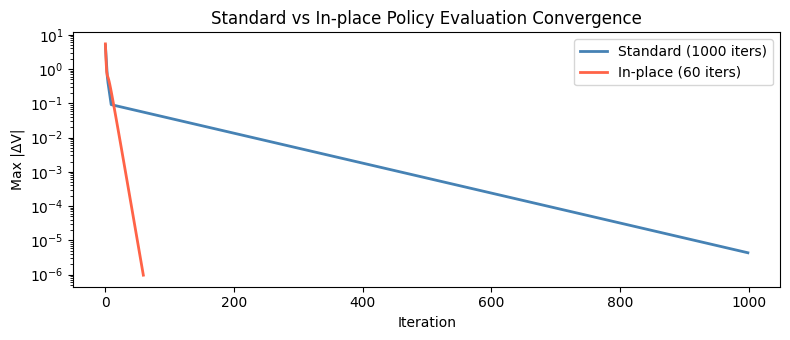


Standard:  1000 iterations
In-place:  60 iterations
In-place typically converges faster — updated values propagate within the same sweep,
so information flows more quickly through the state space.


In [7]:
def policy_evaluation_inplace(env, policy, gamma=0.99, theta=1e-6, max_iter=1000):
    """In-place: update V[s] immediately, reusing updated values in the same sweep."""
    V = np.zeros(env.n_states())
    history = [V.copy()]
    for iteration in range(max_iter):
        delta = 0.0
        for s in range(env.n_states()):
            v_old = V[s]
            v = 0.0
            for a in range(env.n_actions()):
                for prob, ns, reward, done in env.transitions(s, a):
                    v += policy[s, a] * prob * (reward + (0 if done else gamma * V[ns]))
            V[s] = v  # update immediately
            delta = max(delta, abs(V[s] - v_old))
        history.append(V.copy())
        if delta < theta:
            print(f"In-place converged in {iteration+1} iterations (Δ={delta:.2e})")
            break
    return V, history

V_ip, history_ip = policy_evaluation_inplace(env, uniform_policy)

# Compare convergence speed
_, history_std = policy_evaluation(env, uniform_policy)

delta_std = [np.max(np.abs(history_std[i+1] - history_std[i])) for i in range(len(history_std)-1)]
delta_ip  = [np.max(np.abs(history_ip[i+1]  - history_ip[i]))  for i in range(len(history_ip)-1)]

plt.figure(figsize=(8, 3.5))
plt.semilogy(delta_std, color='steelblue', linewidth=2, label=f'Standard ({len(delta_std)} iters)')
plt.semilogy(delta_ip,  color='tomato',    linewidth=2, label=f'In-place ({len(delta_ip)} iters)')
plt.xlabel('Iteration'); plt.ylabel('Max |ΔV|')
plt.title('Standard vs In-place Policy Evaluation Convergence')
plt.legend(); plt.tight_layout(); plt.show()

print(f"\nStandard:  {len(delta_std)} iterations")
print(f"In-place:  {len(delta_ip)} iterations")
print("In-place typically converges faster — updated values propagate within the same sweep,")
print("so information flows more quickly through the state space.")